In [56]:
# ============================================================
# 1. IMPORTS
# ============================================================

import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [57]:
# ============================================================
# 2. PROJECT PATH
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data_pipeline

importlib.reload(src.data_pipeline)

from src.data_pipeline import ModelDatasetBuilder

In [58]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

builder = ModelDatasetBuilder(db_path)

df = builder.build_price_dataset(
    zones="NO1",
    start_date="2020-01-01",
    end_date="2020-12-31",
    add_time_features=False,
    lags=None,
    target_horizon=None,
    include_volumes=True,
    dropna=False
)

df.head()

,price_id,zone_id,delivery_day,hour,price_value,buy_volume_value,sell_volume_value
datetime,,,,,,,
2020-01-01 00:00:00,32,12,2020-01-01,1,31.77,4091.8,1819.6
2020-01-01 01:00:00,52,12,2020-01-01,2,31.57,4021.3,1826.2
2020-01-01 02:00:00,72,12,2020-01-01,3,31.28,3975.7,1836.8
2020-01-01 03:00:00,92,12,2020-01-01,4,30.72,3993.6,1841.5
2020-01-01 04:00:00,112,12,2020-01-01,5,30.27,4041.5,1798.0


In [59]:
# ============================================================
# 4. CREATE TEMPORAL SERIES AND EXOG VARIABLES
# ============================================================

df_model = df[
    [
        "price_value",
        "buy_volume_value",
        "sell_volume_value"
    ]
].asfreq("h").dropna()

ts = df_model["price_value"]

exog = df_model[
    [
        "buy_volume_value",
        "sell_volume_value"
    ]
]

print("Length:", ts.shape)
print("Duplicates:", ts.index.duplicated().sum())
print("Missing price:", ts.isna().sum())
print("Missing exog:")
print(exog.isna().sum())
print("Start:", ts.index.min())
print("End:", ts.index.max())

Length: (8761,)
Duplicates: 0
Missing price: 0
Missing exog:
buy_volume_value     0
sell_volume_value    0
dtype: int64
Start: 2020-01-01 00:00:00
End: 2020-12-31 00:00:00


In [73]:
# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

ts_model = ts["2020-01-01":"2020-12-31"]
exog_model = exog["2020-01-01":"2020-12-31"]

train = ts_model["2020-01-01":"2020-11-30 23:00:00"]
test = ts_model["2020-12-01":"2020-12-07 23:00:00"]

exog_train = exog_model.loc[train.index]
exog_test = exog_model.loc[test.index]

print("Train:", train.shape)
print("Test:", test.shape)
print("Exog train:", exog_train.shape)
print("Exog test:", exog_test.shape)

Train: (8040,)
Test: (168,)
Exog train: (8040, 2)
Exog test: (168, 2)


In [74]:
# ============================================================
# 6. ARIMA ROLLING ONE-STEP FORECAST
# ============================================================

arima_history = list(train)
arima_predictions = []

for t in range(len(test)):
    model = ARIMA(arima_history, order=(3, 0, 3))
    model_fit = model.fit()

    yhat = model_fit.forecast(steps=1)[0]
    arima_predictions.append(yhat)

    arima_history.append(test.iloc[t])

arima_pred_series = pd.Series(arima_predictions, index=test.index)

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimizat

In [75]:
# ============================================================
# 7. SARIMAX ROLLING ONE-STEP FORECAST
# ============================================================

sarimax_history_y = list(train)
sarimax_history_exog = exog_train.copy()

sarimax_predictions = []

for t in range(len(test)):
    model = SARIMAX(
        sarimax_history_y,
        exog=sarimax_history_exog,
        order=(3, 0, 3),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    yhat = model_fit.forecast(
        steps=1,
        exog=exog_test.iloc[[t]]
    )[0]

    sarimax_predictions.append(yhat)

    sarimax_history_y.append(test.iloc[t])
    sarimax_history_exog = pd.concat(
        [sarimax_history_exog, exog_test.iloc[[t]]]
    )

sarimax_pred_series = pd.Series(sarimax_predictions, index=test.index)

c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HUGO\AppData\Local\Temp\ipykernel_25484\1186709323.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yhat = model_fit.forecast(
c:\Users\HUGO\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HUGO\AppData\Local\Temp\ipykernel_25484\1186709323.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, 

Ejecution was working almost 17 minutes.

In [76]:
# ============================================================
# 8. COMPARE RESULTS
# ============================================================

def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results = pd.DataFrame({
    "ARIMA": evaluate_model(test, arima_pred_series),
    "SARIMAX_volumes": evaluate_model(test, sarimax_pred_series)
}).T

results

,MAE,RMSE,R2
ARIMA,0.878556,1.166275,0.871335
SARIMAX_volumes,0.762953,1.048901,0.895929


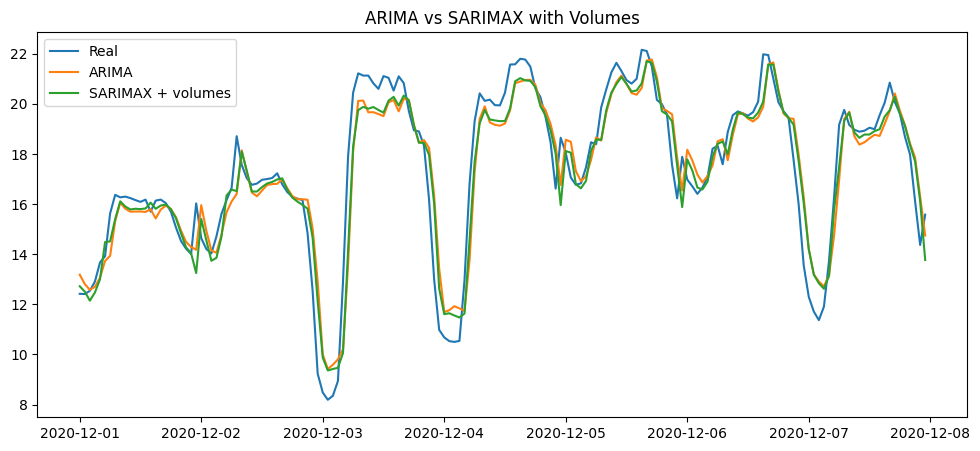

In [77]:
# ============================================================
# 9. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")
plt.plot(test.index, sarimax_pred_series, label="SARIMAX + volumes")

plt.legend()
plt.title("ARIMA vs SARIMAX with Volumes")
plt.show()

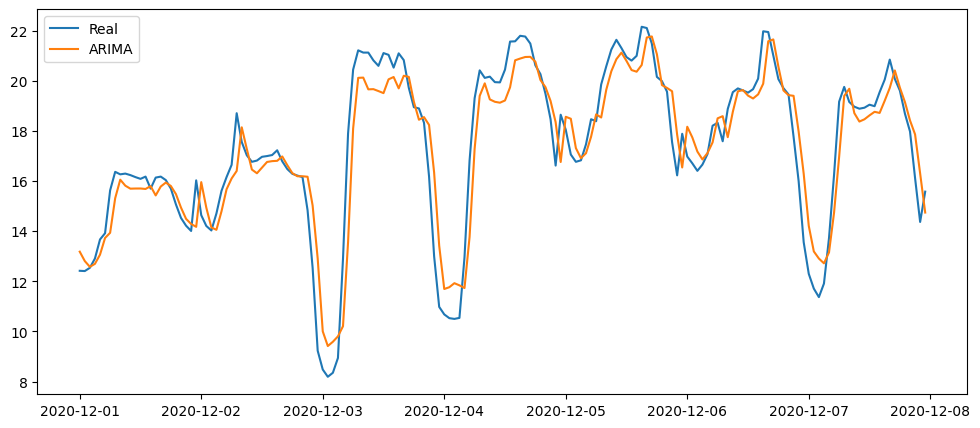

In [78]:
# ============================================================
# 9. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, arima_pred_series, label="ARIMA")

plt.legend()
plt.show()

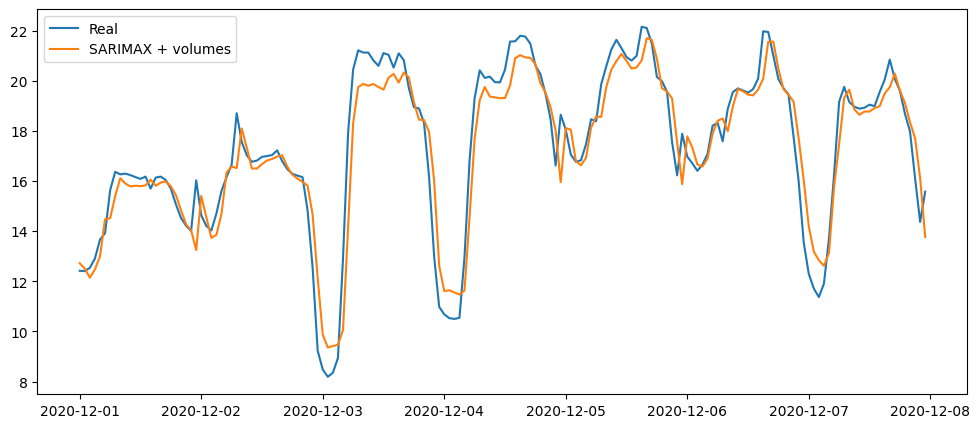

In [79]:
# ============================================================
# 9. PLOT COMPARISON
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, sarimax_pred_series, label="SARIMAX + volumes")

plt.legend()
plt.show()